In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
data = {
    "candidate": [
        "Candidate 1",
        "Candidate 2",
        "Candidate 3",
        "Candidate 4",
        "Candidate 5"
    ],

    "resume": [
        "Python developer with experience in machine learning, data analysis, pandas, numpy, scikit-learn and SQL.",
        "Frontend developer skilled in HTML, CSS, JavaScript, React and responsive web design.",
        "Java developer with experience in Spring Boot, Java, MySQL and backend development.",
        "Data analyst experienced in Python, Excel, SQL, data visualization, pandas and statistics.",
        "Cloud engineer with knowledge of AWS, Docker, Kubernetes, Linux and cloud computing."
    ]
}

df = pd.DataFrame(data)

print("Resume dataset created successfully!")
print("Number of candidates:", len(df))

df

Resume dataset created successfully!
Number of candidates: 5


,candidate,resume
0,Candidate 1,Python developer with experience in machine le...
1,Candidate 2,"Frontend developer skilled in HTML, CSS, JavaS..."
2,Candidate 3,"Java developer with experience in Spring Boot,..."
3,Candidate 4,"Data analyst experienced in Python, Excel, SQL..."
4,Candidate 5,"Cloud engineer with knowledge of AWS, Docker, ..."


In [4]:
job_description = """
We are looking for a Python Developer with experience in
machine learning, data analysis, pandas, numpy, scikit-learn,
SQL and Python programming.
"""

print("Job Description:")
print(job_description)

Job Description:

We are looking for a Python Developer with experience in
machine learning, data analysis, pandas, numpy, scikit-learn,
SQL and Python programming.



In [5]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nCandidate Resumes:")
print(df[["candidate", "resume"]])

Dataset Shape:
(5, 2)

Column Names:
['candidate', 'resume']

Missing Values:
candidate    0
resume       0
dtype: int64

Candidate Resumes:
     candidate                                             resume
0  Candidate 1  Python developer with experience in machine le...
1  Candidate 2  Frontend developer skilled in HTML, CSS, JavaS...
2  Candidate 3  Java developer with experience in Spring Boot,...
3  Candidate 4  Data analyst experienced in Python, Excel, SQL...
4  Candidate 5  Cloud engineer with knowledge of AWS, Docker, ...


In [6]:
# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2)
)

# Combine resumes and job description
all_text = df["resume"].tolist() + [job_description]

# Fit TF-IDF on all text
tfidf_matrix = vectorizer.fit_transform(all_text)

# Separate resume vectors and job description vector
resume_vectors = tfidf_matrix[:-1]
job_vector = tfidf_matrix[-1]

print("TF-IDF conversion completed!")

print("Resume TF-IDF shape:", resume_vectors.shape)
print("Job Description TF-IDF shape:", job_vector.shape)

TF-IDF conversion completed!
Resume TF-IDF shape: (5, 89)
Job Description TF-IDF shape: (1, 89)


In [7]:
# Calculate cosine similarity between each resume and the job description
similarity_scores = cosine_similarity(
    resume_vectors,
    job_vector
).flatten()

# Add scores to the dataset
df["match_score"] = similarity_scores * 100

print("Resume matching completed!")

print("\nCandidate Matching Scores:")
print(
    df[["candidate", "match_score"]]
    .sort_values(by="match_score", ascending=False)
)

Resume matching completed!

Candidate Matching Scores:
     candidate  match_score
0  Candidate 1    85.588088
3  Candidate 4    15.274521
2  Candidate 3     6.969848
1  Candidate 2     1.817913
4  Candidate 5     0.000000


In [8]:
# Sort candidates by matching score
ranked_candidates = df.sort_values(
    by="match_score",
    ascending=False
).reset_index(drop=True)

# Create ranking numbers
ranked_candidates["rank"] = ranked_candidates.index + 1

# Display the ranked candidates
print("==========================================")
print("       RESUME SCREENING RESULTS")
print("==========================================")

print(
    ranked_candidates[
        ["rank", "candidate", "match_score"]
    ]
)

       RESUME SCREENING RESULTS
   rank    candidate  match_score
0     1  Candidate 1    85.588088
1     2  Candidate 4    15.274521
2     3  Candidate 3     6.969848
3     4  Candidate 2     1.817913
4     5  Candidate 5     0.000000


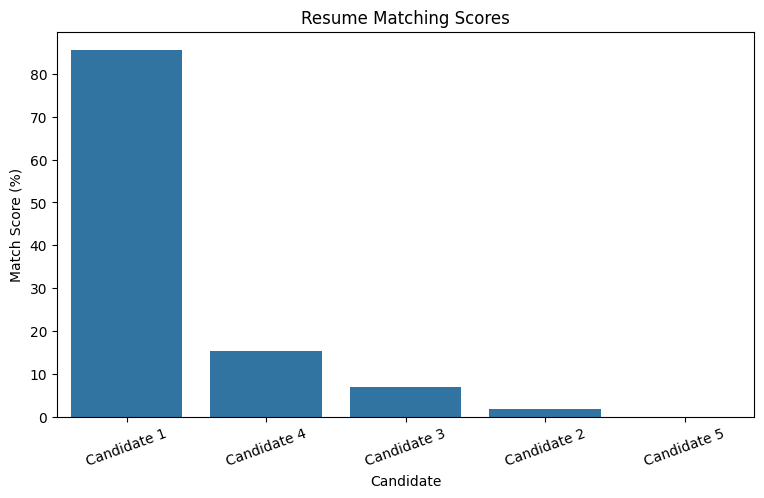

In [9]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=ranked_candidates,
    x="candidate",
    y="match_score"
)

plt.title("Resume Matching Scores")
plt.xlabel("Candidate")
plt.ylabel("Match Score (%)")
plt.xticks(rotation=20)

plt.show()

In [10]:
def screen_resumes(job_description):
    # Convert resumes and job description into TF-IDF features
    all_text = df["resume"].tolist() + [job_description]

    tfidf = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2)
    )

    tfidf_matrix = tfidf.fit_transform(all_text)

    resume_vectors = tfidf_matrix[:-1]
    job_vector = tfidf_matrix[-1]

    # Calculate similarity
    scores = cosine_similarity(
        resume_vectors,
        job_vector
    ).flatten()

    # Create result dataframe
    results = df[["candidate", "resume"]].copy()
    results["match_score"] = scores * 100

    # Rank candidates
    results = results.sort_values(
        by="match_score",
        ascending=False
    ).reset_index(drop=True)

    results["rank"] = results.index + 1

    return results


print("Resume screening function created successfully!")

Resume screening function created successfully!


In [11]:
new_job_description = """
We are looking for a Data Analyst with strong skills in
Python, SQL, data analysis, pandas, Excel, statistics
and data visualization.
"""

results = screen_resumes(new_job_description)

print("==========================================")
print("       DATA ANALYST RESUME SCREENING")
print("==========================================")

print(
    results[
        ["rank", "candidate", "match_score"]
    ]
)

       DATA ANALYST RESUME SCREENING
   rank    candidate  match_score
0     1  Candidate 4    47.971685
1     2  Candidate 1    23.316816
2     3  Candidate 2     0.000000
3     4  Candidate 3     0.000000
4     5  Candidate 5     0.000000


In [12]:
# Get the best candidate
best_candidate = results.iloc[0]

print("==========================================")
print("          BEST CANDIDATE")
print("==========================================")

print("Rank:", int(best_candidate["rank"]))
print("Candidate:", best_candidate["candidate"])
print("Match Score:", f"{best_candidate['match_score']:.2f}%")

print("\nResume:")
print(best_candidate["resume"])

          BEST CANDIDATE
Rank: 1
Candidate: Candidate 4
Match Score: 47.97%

Resume:
Data analyst experienced in Python, Excel, SQL, data visualization, pandas and statistics.


In [13]:
# Set the minimum score required for shortlisting
minimum_score = 20

# Select candidates above the threshold
shortlisted_candidates = results[
    results["match_score"] >= minimum_score
].copy()

print("==========================================")
print("       SHORTLISTED CANDIDATES")
print("==========================================")

if len(shortlisted_candidates) > 0:
    print(
        shortlisted_candidates[
            ["rank", "candidate", "match_score"]
        ]
    )
else:
    print("No candidates met the minimum matching score.")

print("\nMinimum Match Score:", minimum_score, "%")
print("Number of Shortlisted Candidates:", len(shortlisted_candidates))

       SHORTLISTED CANDIDATES
   rank    candidate  match_score
0     1  Candidate 4    47.971685
1     2  Candidate 1    23.316816

Minimum Match Score: 20 %
Number of Shortlisted Candidates: 2


In [14]:
# Save ranked screening results
results.to_csv(
    "resume_screening_results.csv",
    index=False
)

# Save shortlisted candidates
shortlisted_candidates.to_csv(
    "shortlisted_candidates.csv",
    index=False
)

print("Screening results saved successfully!")

print("\nFiles created:")
print("1. resume_screening_results.csv")
print("2. shortlisted_candidates.csv")

Screening results saved successfully!

Files created:
1. resume_screening_results.csv
2. shortlisted_candidates.csv


In [15]:
print("==========================================")
print("      AI RESUME SCREENING SYSTEM")
print("==========================================")

user_job = input("\nEnter the job description: ")

if user_job.strip() == "":
    print("Please enter a valid job description.")
else:
    screening_results = screen_resumes(user_job)

    print("\nResume Screening Results:")
    print("-" * 50)

    print(
        screening_results[
            ["rank", "candidate", "match_score"]
        ].to_string(index=False)
    )

    best = screening_results.iloc[0]

    print("\nBest Matching Candidate:")
    print("Candidate:", best["candidate"])
    print("Match Score:", f"{best['match_score']:.2f}%")

      AI RESUME SCREENING SYSTEM

Enter the job description: Enter the job description:

Resume Screening Results:
--------------------------------------------------
 rank   candidate  match_score
    1 Candidate 1          0.0
    2 Candidate 2          0.0
    3 Candidate 3          0.0
    4 Candidate 4          0.0
    5 Candidate 5          0.0

Best Matching Candidate:
Candidate: Candidate 1
Match Score: 0.00%


In [16]:
import os

print("==========================================")
print("          PROJECT FILE CHECK")
print("==========================================")

files = [
    "resume_screening_results.csv",
    "shortlisted_candidates.csv"
]

for file in files:
    if os.path.exists(file):
        size = os.path.getsize(file)
        print(f"✓ {file}  ({size} bytes)")
    else:
        print(f"✗ {file}  (Not found)")

          PROJECT FILE CHECK
✓ resume_screening_results.csv  (615 bytes)
✓ shortlisted_candidates.csv  (300 bytes)


In [17]:
print("==========================================")
print("       AI RESUME SCREENING SYSTEM")
print("==========================================")

print("\nProject Summary:")
print("• Domain: Artificial Intelligence & NLP")
print("• Platform: Google Colab")
print("• Language: Python")
print("• Technique: TF-IDF")
print("• Similarity Method: Cosine Similarity")
print("• Main Task: Resume-Job Matching")
print("• Features: Ranking and Shortlisting")
print("• Output: Candidate Matching Scores")

print("\nProject completed successfully!")

       AI RESUME SCREENING SYSTEM

Project Summary:
• Domain: Artificial Intelligence & NLP
• Platform: Google Colab
• Language: Python
• Technique: TF-IDF
• Similarity Method: Cosine Similarity
• Main Task: Resume-Job Matching
• Features: Ranking and Shortlisting
• Output: Candidate Matching Scores

Project completed successfully!
